In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# 1. Capa de Extracción (E)
url_base = "https://api.open-meteo.com/v1/forecast"
parametros = {
    "latitude": 19.4,
    "longitude": -99.0,
    "hourly": "temperature_2m", # Pedimos el historial por hora
    "forecast_days": 1 # Solo el pronóstico de 1 día
}

try:
    respuesta = requests.get(url_base, params=parametros, timeout=10)
    respuesta.raise_for_status()
    datos_clima = respuesta.json()
    
    # Aquí están tus dos listas crudas:
    lista_horas = datos_clima["hourly"]["time"]
    lista_temperaturas = datos_clima["hourly"]["temperature_2m"]

except requests.exceptions.RequestException as e:
    print(f"Error de red: {e}")

In [19]:
diccionario_clima = {
    'hourly': lista_horas,
    'temperature': lista_temperaturas
}

df_pronostico = pd.DataFrame(diccionario_clima)

df_pronostico

,hourly,temperature
0,2026-08-27T00:00,22.0
1,2026-08-27T01:00,20.2
2,2026-08-27T02:00,19.4
3,2026-08-27T03:00,18.4
4,2026-08-27T04:00,17.9
5,2026-08-27T05:00,17.5
6,2026-08-27T06:00,16.8
7,2026-08-27T07:00,16.4
8,2026-08-27T08:00,16.3
9,2026-08-27T09:00,15.7


In [21]:
df_pronostico['hourly'] = pd.to_datetime(df_pronostico['hourly'])

df_pronostico

,hourly,temperature
0,2026-08-27 00:00:00,22.0
1,2026-08-27 01:00:00,20.2
2,2026-08-27 02:00:00,19.4
3,2026-08-27 03:00:00,18.4
4,2026-08-27 04:00:00,17.9
5,2026-08-27 05:00:00,17.5
6,2026-08-27 06:00:00,16.8
7,2026-08-27 07:00:00,16.4
8,2026-08-27 08:00:00,16.3
9,2026-08-27 09:00:00,15.7


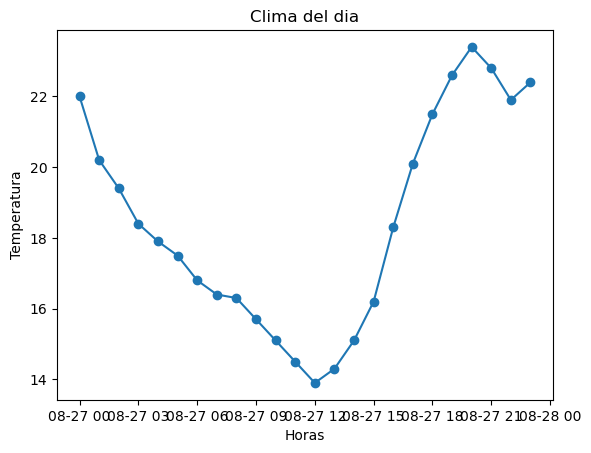

In [22]:
plt.plot(df_pronostico['hourly'], df_pronostico['temperature'], marker='o')

plt.title('Clima del dia')
plt.xlabel('Horas')
plt.ylabel('Temperatura')

plt.show()

In [23]:
maxima = df_pronostico.loc[df_pronostico['temperature'].idxmax()]
minima = df_pronostico.loc[df_pronostico['temperature'].idxmin()]

print(maxima)
print(minima)

hourly         2026-08-27 20:00:00
temperature                   23.4
Name: 20, dtype: object
hourly         2026-08-27 12:00:00
temperature                   13.9
Name: 12, dtype: object
